# Calculus

In [10]:
# ---- Units ----
p = 1e-12
n = 1e-9
u = 1e-6
m = 1e-3
k = 1e3
M = 1e6
G = 1e9
import sympy as sp

In [ ]:


# Define variables
s = sp.symbols('s')
t = sp.symbols('t') # Define 't' as a sympy symbol



C =100 * u;L = 2* m; z = 0.57
wn = 1/(L*C)**(1/2)
R = 2 * z * wn * L
sqrt = (1-z**2)**(1/2)


5.09823498869952

In [16]:
fs = wn**2/(s**2 + 2*wn*z*s + wn**2)
t = 15e-4
laplace_ft = sp.inverse_laplace_transform(fs, s, t)
ft = wn * sp.E**(-z*wn*t)* sp.sin(wn*sqrt*t) # rads
#print(f"wn = {wn}, a = {sp.E**(-z*wn*t)}, b = {sp.sin(wn*sqrt*t)}, ft_con = {ft/sqrt}")
print(f"ft_con = {ft/sqrt}")

ft_con = 151.335722039149


In [28]:
# start from t =0.0001 to 20 samples
for i in range(0,20):
    t = 0.1 * m * i
    ft = wn * sp.E**(-z*wn*t)* sp.sin(wn*sqrt*t)/sqrt # rads:
    print(ft)

0
437.694004677546
757.662502462525
972.332099330372
1095.96137599766
1143.60196579526
1130.25854908337
1070.23992531754
976.686689404936
861.256533516959
733.945538017286
603.022706608012
475.055141376735
355.002355891130
246.360023940144
151.335722039149
71.0417422979904
5.69265995666676
-45.2020978685439
-82.6580213011899


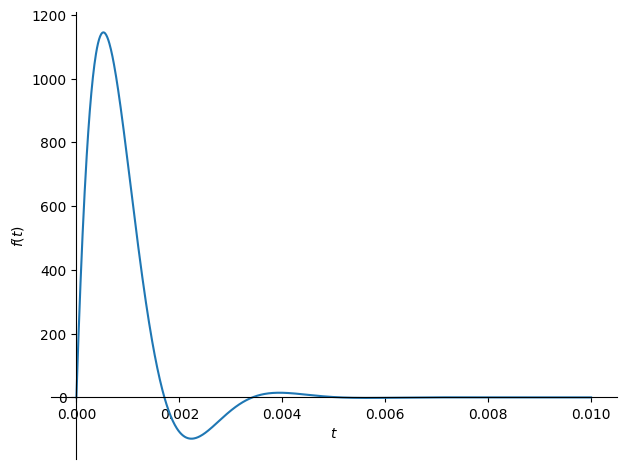

In [109]:
plot = sp.plot(laplace_ft, (t, 0, 0.01), show=False);plot.show()

In [122]:
for i in range(0, 11) :
    t = i*0.001
    print(f"f({t}) = {wn * sp.E**(-z*wn*t)* sp.sin(wn*sqrt*t)}" )


f(0.0) = 0
f(0.001) = 603.042455577324
f(0.002) = -88.7809849940113
f(0.003) = -34.0576372693854
f(0.004) = 11.9523136475549
f(0.005) = 0.901984005484630
f(0.006) = -1.06687222259932
f(0.007) = 0.0865762351262609
f(0.008) = 0.0706308008861705
f(0.009000000000000001) = -0.0171643774386986
f(0.01) = -0.00299286950989524


f(0.0) = 0
f(0.001) = 603.042455577324
f(0.002) = -88.7809849940113
f(0.003) = -34.0576372693854
f(0.004) = 11.9523136475549
f(0.005) = 0.901984005484630
f(0.006) = -1.06687222259932
f(0.007) = 0.0865762351262609
f(0.008) = 0.0706308008861705
f(0.009000000000000001) = -0.0171643774386986
f(0.01) = -0.00299286950989524


1.00000000000000

In [46]:

# NOW CORRECT: Match C code's actual parameters from main.c
import numpy as np

print("=" * 80)
print("C CODE PARAMETERS FROM main.c")
print("=" * 80)
print("float t_end_target = 0.010f;")
print("float *y = plot(200, wn, t_end_target);")
print("float *temp = linspace(0.0f, t_end_target, 20);")
print()

# Create x values EXACTLY as C does
x_c = np.linspace(0.0, 0.010, 20)
print(f"C's x-values (linspace(0, 0.010, 20)):")
print(f"Spacing: {x_c[1] - x_c[0]:.6f} seconds")
print(f"First 5 x: {x_c[:5]}")
print(f"Last 5 x:  {x_c[-5:]}")
print()

# Compute y-values using H(t) formula at C's 20 x-points
C_val = 100e-6
L_val = 2e-3  
z = 0.57
wn_val = 1.0 / np.sqrt(L_val * C_val)

def H(t, wn, zeta):
    if zeta >= 1.0:
        return 0.0
    omega_d = np.sqrt(1.0 - zeta * zeta)
    a = np.exp(-zeta * wn * t)
    b = np.sin(wn * omega_d * t)
    num = wn * a * b
    den = omega_d
    return num / den

y_c = np.array([H(t, wn_val, z) for t in x_c])

print("EXPECTED y-values (from plot at C's 20 x-points):")
for i in range(min(11, len(x_c))):
    print(f"  y[{i}] = H({x_c[i]:.6f}s) = {y_c[i]:.6f}")
print()

print("=" * 80)
print("NEWTON COEFFICIENTS (grado=10, first 11 points)")
print("=" * 80)

def divided_differences(x, y):
    n = len(x)
    a = y.copy().astype(float)
    for j in range(1, n):
        for i in range(n-1, j-1, -1):
            a[i] = (a[i] - a[i-1]) / (x[i] - x[i-j])
    return a

# Use first 11 points (indices 0-10) for degree 10 polynomial
coefs = divided_differences(x_c[:11], y_c[:11])

print("Expected Python a[] coefficients:")
for i in range(len(coefs)):
    print(f"a[{i}] = {coefs[i]:.6e}")

print()
print("=" * 80)
print("COMPARE YOUR C OUTPUT WITH ABOVE")
print("=" * 80)


C CODE PARAMETERS FROM main.c
float t_end_target = 0.010f;
float *y = plot(200, wn, t_end_target);
float *temp = linspace(0.0f, t_end_target, 20);

C's x-values (linspace(0, 0.010, 20)):
Spacing: 0.000526 seconds
First 5 x: [0.         0.00052632 0.00105263 0.00157895 0.00210526]
Last 5 x:  [0.00789474 0.00842105 0.00894737 0.00947368 0.01      ]

EXPECTED y-values (from plot at C's 20 x-points):
  y[0] = H(0.000000s) = 0.000000
  y[1] = H(0.000526s) = 1145.402258
  y[2] = H(0.001053s) = 665.033588
  y[3] = H(0.001579s) = 86.699149
  y[4] = H(0.002105s) = -123.512166
  y[5] = H(0.002632s) = -94.377148
  y[6] = H(0.003158s) = -22.508342
  y[7] = H(0.003684s) = 11.603134
  y[8] = H(0.004211s) = 12.620961
  y[9] = H(0.004737s) = 4.294624
  y[10] = H(0.005263s) = -0.805818

NEWTON COEFFICIENTS (grado=10, first 11 points)
Expected Python a[] coefficients:
a[0] = 0.000000e+00
a[1] = 2.176264e+06
a[2] = -2.934517e+09
a[3] = 1.746536e+12
a[4] = -5.765164e+14
a[5] = 9.633069e+16
a[6] = 3.932209

In [42]:

# Newton Interpolation with the 20 sample points
import numpy as np

# The 20 sample values from H(t)
y_samples = np.array([441.495, 762.995, 977.341, 1099.257, 1144.266, 1127.811, 
                      1064.581, 968.0268, 850.037, 720.764, 588.554,
                      455.991, 340.025, 232.058, 138.208, 59.473, 
            -4.0522, -52.975, -88.42])

# Time samples: t = 0.1*m*i for i=0 to 18 (19 points)
m_val = 1e-3
x_samples = np.array([0.1 * m_val * i for i in range(len(y_samples))])

print(f"Number of samples: {len(x_samples)}")
print(f"Time range: {x_samples[0]} to {x_samples[-1]} seconds")
print(f"X-samples (times in seconds):")
print(x_samples)
print()

# Newton Divided Differences
def divided_differences(x, y):
    n = len(x)
    a = y.copy().astype(float)
    for j in range(1, n):
        for i in range(n-1, j-1, -1):
            a[i] = (a[i] - a[i-1]) / (x[i] - x[i-j])
    return a

# Horner's nested evaluation
def newton_eval(x_eval, x_nodes, a):
    result = a[-1]
    for i in range(len(a)-2, -1, -1):
        result = result * (x_eval - x_nodes[i]) + a[i]
    return result

# Compute coefficients
a = divided_differences(x_samples, y_samples)

print("Newton Divided Differences Coefficients a[]:")
for i, coef in enumerate(a):
    print(f"  a[{i}] = {coef:.6e}")
print()

# Test evaluation at some points
print("=" * 70)
print("NEWTON INTERPOLATION RESULTS")
print("=" * 70)

test_points = float(input("Enter a time value to evaluate P(t) (e.g., 0.0018): "))

p_val = newton_eval(test_points, x_samples, a)
print(f"P({test_points:.4f}) = {p_val:.6f}")


Number of samples: 19
Time range: 0.0 to 0.0018000000000000002 seconds
X-samples (times in seconds):
[0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009
 0.001  0.0011 0.0012 0.0013 0.0014 0.0015 0.0016 0.0017 0.0018]

Newton Divided Differences Coefficients a[]:
  a[0] = 4.414950e+02
  a[1] = 3.215000e+06
  a[2] = -5.357700e+09
  a[3] = 2.454000e+12
  a[4] = 3.329167e+14
  a[5] = -7.325000e+17
  a[6] = 2.847222e+20
  a[7] = -3.015873e+22
  a[8] = -3.571429e+25
  a[9] = 9.314374e+28
  a[10] = -2.452601e+32
  a[11] = -9.429614e+36
  a[12] = 9.901721e+40
  a[13] = -4.992246e+44
  a[14] = 1.668467e+48
  a[15] = -4.175885e+51
  a[16] = 8.356647e+54
  a[17] = -1.393249e+58
  a[18] = 1.990788e+61

NEWTON INTERPOLATION RESULTS
P(0.0020) = 5382143.958000
